# 📐 Projeto Fatorial 2² com Replicações — Consenso entre LLMs

Análise de um **projeto fatorial completo 2² com replicação** sobre a anotação
automática por consenso entre 3 LLMs (**Llama3.1-8B**, **Qwen3-8B**, **DeepSeek-R1-8B**).

O consenso é construído **reutilizando a mesma máquina do notebook
`analise_consenso_llms_extra.ipynb`** — `ConsensusCalculator` +
`ConsensusEvaluator` — variando apenas a estratégia de resolução:

| Consenso | Estratégia (`ConsensusCalculator`) | threshold |
|----------|-------------------------------------|-----------|
| **2×1 — Maioria**      | `majority_vote`   | 0.8 |
| **3×0 — Unanimidade**  | `unanimous_only`  | 1.0 |

**Fatores**

| Fator | -1 | +1 |
|-------|----|----|
| **B — Domínio**    | MovieReview (geral)   | Books (técnico)        |
| **C — Consenso**   | Maioria (2×1)         | Unanimidade (3×0)      |

**Tratamentos**

| Trat. | Domínio | Consenso | B | C | BC |
|-------|---------|----------|---|---|----|
| (1)   | MovieReview | 2×1  | -1 | -1 | +1 |
| b     | Books       | 2×1  | +1 | -1 | -1 |
| c     | MovieReview | 3×0  | -1 | +1 | -1 |
| bc    | Books       | 3×0  | +1 | +1 | +1 |

Cada tratamento tem **5 replicações** (as 5 últimas pastas de
`data/results/<dataset>`). As respostas analisadas no projeto fatorial são
**F1 Macro** e **Acurácia**.

> Os modelos individuais **não** entram no projeto fatorial — servem apenas
> para benchmark posterior.


## 1) Setup e configuração

In [1]:
import os
import sys
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
)
from loguru import logger

# Localiza a raiz do projeto (a que contém data/results) e a coloca no path
ROOT = Path.cwd()
while not (ROOT / "data" / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Reutiliza a MESMA máquina de consenso do notebook analise_consenso_llms_extra
from src.llm_annotation_system.consensus.consensus_calculator import ConsensusCalculator
from src.llm_annotation_system.consensus.consensus_evaluator import ConsensusEvaluator

# Silencia os logs verbosos do cálculo de consenso (rodamos 20 vezes)
logger.remove()

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"] = 110

# Os 3 modelos que compõem o consenso (usamos as colunas "<modelo>_consensus",
# exatamente como o ConsensusCalculator espera)
MODELS = ["deepseek-r1-8b", "qwen3-8b", "llama3.1-8b"]
CONS_COLS = [f"{m}_consensus" for m in MODELS]

# Datasets / fatores
DATASETS = ["movie_review", "books"]   # B = -1 (movie), +1 (books)
N_REPS = 5                              # nº de replicações por dataset
INVALID = -1                            # código de predição/label inválida

RESULTS_DIR = ROOT / "data" / "results"
print("Raiz do projeto:", ROOT)
print("Resultados em  :", RESULTS_DIR)

Raiz do projeto: c:\Users\gabri\Documents\GitHub\llm-annotation
Resultados em  : c:\Users\gabri\Documents\GitHub\llm-annotation\data\results


## 2) Selecionar as 5 réplicas de cada dataset

As replicações são as **5 últimas pastas** (ordem cronológica pelo nome) de cada
dataset que contenham `annotations.csv`.

In [2]:
def last_n_replication_folders(dataset, n=N_REPS):
    """Retorna as n últimas pastas (ordenadas por nome) com annotations.csv."""
    folders = sorted(
        d for d in glob.glob(str(RESULTS_DIR / dataset / "*") + os.sep)
        if os.path.exists(os.path.join(d, "annotations.csv"))
    )
    chosen = folders[-n:]
    if len(chosen) < n:
        raise ValueError(f"{dataset}: encontrei só {len(chosen)} pastas (esperado {n}).")
    return chosen


REPLICATION_FOLDERS = {ds: last_n_replication_folders(ds) for ds in DATASETS}

for ds, folders in REPLICATION_FOLDERS.items():
    print(f"\n== {ds} ==")
    for i, f in enumerate(folders, start=1):
        print(f"  rep{i}: {os.path.basename(os.path.normpath(f))}")


== movie_review ==
  rep1: 2026-04-09_13-17-23
  rep2: 2026-05-17_14-44-16
  rep3: 2026-05-17_21-51-31
  rep4: 2026-05-18_06-14-02
  rep5: 2026-05-18_22-29-27

== books ==
  rep1: 2026-04-09_13-21-37
  rep2: 2026-05-20_21-44-17
  rep3: 2026-05-23_00-20-50
  rep4: 2026-05-24_20-47-50
  rep5: 2026-05-26_18-26-27


## 3) Consenso via `ConsensusCalculator` / `ConsensusEvaluator`

Para cada réplica, instanciamos a **mesma** dupla de classes do notebook de
consenso, variando só a estratégia:

- **2×1 — Maioria**: `default_strategy="majority_vote"`, `threshold=0.8`. O
  `resolved_annotation` é a classe majoritária entre os 3 modelos.
- **3×0 — Unanimidade**: `default_strategy="unanimous_only"`, `threshold=1.0`. O
  `resolved_annotation` só existe quando os 3 modelos concordam; caso contrário
  fica `NaN` (`needs_review`).

Em seguida aplicamos **a mesma limpeza do notebook de consenso**: descartamos as
linhas com `ground_truth` inválido, com `resolved_annotation == -1` e os
**casos problemáticos** (`is_problematic`, empates).

> Isolamos as 3 colunas `*_consensus` dos modelos-alvo antes de chamar o
> `ConsensusCalculator` — assim, mesmo em pastas que contenham outros modelos, o
> consenso é calculado apenas sobre Llama/Qwen/DeepSeek.

In [3]:
# Estratégia de resolução por tipo de consenso (parâmetros do ConsensusCalculator)
STRAT_CFG = {
    "2x1": {"strategy": "majority_vote",  "threshold": 0.8},   # Maioria
    "3x0": {"strategy": "unanimous_only", "threshold": 1.0},   # Unanimidade
}


def get_categories(df):
    """Categorias válidas a partir do ground_truth (exclui -1)."""
    return sorted(int(v) for v in df["ground_truth"].unique() if v != INVALID)


def quality_metrics(y_true, y_pred):
    return {
        "accuracy":        accuracy_score(y_true, y_pred),
        "f1_macro":        f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":    recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def evaluate_replication(df_raw, categories, consenso, output_dir):
    """Roda o ConsensusCalculator/Evaluator numa réplica e devolve as métricas."""
    cfg = STRAT_CFG[consenso]
    calculator = ConsensusCalculator(
        consensus_threshold=cfg["threshold"],
        default_strategy=cfg["strategy"],
    )
    evaluator = ConsensusEvaluator(
        categories=categories,
        calculator=calculator,
        output_dir=output_dir,
    )

    # Isola apenas os 3 modelos-alvo (o calculator usa todas as colunas *_consensus)
    sub = df_raw[["text_id", "text", "ground_truth"] + CONS_COLS].copy()
    dfc = evaluator.compute_consensus(sub)

    # Limpeza idêntica ao notebook de consenso ---------------------------------
    dfc = dfc[dfc["ground_truth"] != INVALID]            # ground-truth válido
    total = len(dfc)
    covered = dfc[
        dfc["resolved_annotation"].notna()               # consenso resolvido
        & (dfc["resolved_annotation"] != INVALID)        # não-inválido
        & (~dfc["is_problematic"])                       # remove casos problemáticos
    ]

    y_true = covered["ground_truth"].astype(int)
    y_pred = covered["resolved_annotation"].astype(int)
    metrics = quality_metrics(y_true, y_pred)

    return {
        "coverage": len(covered) / total if total else 0.0,
        "n_total": total,
        "n_covered": len(covered),
        **metrics,
    }

## 4) Métricas por replicação

Para cada `(dataset, réplica, estratégia)` calculamos **Accuracy, F1 Macro,
Precision Macro e Recall Macro** usando a função acima. A coluna `coverage`
fica na tabela apenas como referência (não entra no projeto fatorial).

In [4]:
rows = []
for ds in DATASETS:
    for rep_idx, folder in enumerate(REPLICATION_FOLDERS[ds], start=1):
        df_raw = pd.read_csv(os.path.join(folder, "annotations.csv"))
        categories = get_categories(df_raw)
        for consenso in STRAT_CFG:
            res = evaluate_replication(df_raw, categories, consenso, folder)
            rows.append({
                "dataset": ds,
                "replica": rep_idx,
                "consenso": consenso,
                **res,
            })

df_results = pd.DataFrame(rows)
print("Linhas:", len(df_results), "(esperado 2×2×5 = 20)")
df_results

Linhas: 20 (esperado 2×2×5 = 20)


,dataset,replica,consenso,coverage,n_total,n_covered,accuracy,f1_macro,precision_macro,recall_macro
0,movie_review,1,2x1,0.9992,10662,10653,0.9135,0.9135,0.9138,0.9135
1,movie_review,1,3x0,0.8982,10662,9577,0.9454,0.9454,0.9456,0.9454
2,movie_review,2,2x1,0.9988,10662,10649,0.9131,0.9131,0.9133,0.9131
3,movie_review,2,3x0,0.9025,10662,9622,0.9441,0.9441,0.9443,0.9441
4,movie_review,3,2x1,0.9989,10662,10650,0.9124,0.9124,0.9126,0.9124
5,movie_review,3,3x0,0.8980,10662,9575,0.9450,0.9450,0.9451,0.9450
6,movie_review,4,2x1,0.9987,10662,10648,0.9142,0.9142,0.9143,0.9142
7,movie_review,4,3x0,0.9018,10662,9615,0.9425,0.9425,0.9426,0.9424
8,movie_review,5,2x1,0.9994,10662,10656,0.9126,0.9126,0.9129,0.9126
9,movie_review,5,3x0,0.9025,10662,9622,0.9443,0.9443,0.9445,0.9443


### Tabela 1 — Resultados por réplica

In [5]:
cols_show = ["dataset", "replica", "consenso", "f1_macro", "accuracy",
             "precision_macro", "recall_macro", "coverage", "n_covered", "n_total"]
tabela1 = df_results[cols_show].sort_values(["dataset", "consenso", "replica"]).reset_index(drop=True)
tabela1

,dataset,replica,consenso,f1_macro,accuracy,precision_macro,recall_macro,coverage,n_covered,n_total
0,books,1,2x1,0.7372,0.7235,0.7739,0.7312,0.9825,33005,33594
1,books,2,2x1,0.7366,0.7230,0.7729,0.7312,0.9833,33034,33594
2,books,3,2x1,0.7376,0.7238,0.7737,0.7322,0.9832,33029,33594
3,books,4,2x1,0.7377,0.7236,0.7737,0.7324,0.9832,33029,33594
4,books,5,2x1,0.7375,0.7238,0.7735,0.7323,0.9834,33036,33594
5,books,1,3x0,0.7962,0.7902,0.8253,0.7940,0.7385,24810,33594
6,books,2,3x0,0.7989,0.7927,0.8283,0.7963,0.7364,24739,33594
7,books,3,3x0,0.7989,0.7931,0.8276,0.7972,0.7346,24678,33594
8,books,4,3x0,0.8006,0.7938,0.8293,0.7988,0.7406,24879,33594
9,books,5,3x0,0.7987,0.7933,0.8275,0.7964,0.7355,24709,33594


## 5) Codificação do projeto fatorial

| Fator | Variável | Mapa |
|-------|----------|------|
| Domínio  | **B** | MovieReview = -1, Books = +1 |
| Consenso | **C** | 2×1 = -1, 3×0 = +1 |
| Interação | **BC** | B × C |

In [6]:
B_MAP = {"movie_review": -1, "books": +1}
C_MAP = {"2x1": -1, "3x0": +1}

df_results["B"]  = df_results["dataset"].map(B_MAP)
df_results["C"]  = df_results["consenso"].map(C_MAP)
df_results["BC"] = df_results["B"] * df_results["C"]

TREAT_NAME = {(-1, -1): "(1)", (+1, -1): "b", (-1, +1): "c", (+1, +1): "bc"}
df_results["tratamento"] = [TREAT_NAME[(b, c)] for b, c in zip(df_results["B"], df_results["C"])]
df_results[["dataset", "consenso", "tratamento", "B", "C", "BC", "f1_macro", "accuracy"]].head(20)

,dataset,consenso,tratamento,B,C,BC,f1_macro,accuracy
0,movie_review,2x1,(1),-1,-1,1,0.9135,0.9135
1,movie_review,3x0,c,-1,1,-1,0.9454,0.9454
2,movie_review,2x1,(1),-1,-1,1,0.9131,0.9131
3,movie_review,3x0,c,-1,1,-1,0.9441,0.9441
4,movie_review,2x1,(1),-1,-1,1,0.9124,0.9124
5,movie_review,3x0,c,-1,1,-1,0.9450,0.9450
6,movie_review,2x1,(1),-1,-1,1,0.9142,0.9142
7,movie_review,3x0,c,-1,1,-1,0.9425,0.9425
8,movie_review,2x1,(1),-1,-1,1,0.9126,0.9126
9,movie_review,3x0,c,-1,1,-1,0.9443,0.9443


## 6) Função de análise fatorial 2² com replicação

Modelo de regressão: $y = q_0 + q_B x_B + q_C x_C + q_{BC} x_B x_C + e$

- $q_0 = \bar{y}$ (média geral)
- $q_i = \dfrac{\sum x_i\, y}{N}$, com $N = 2^k r = 20$
- **Efeito** de um fator $= 2 q_i$ (variação de $-1$ para $+1$)
- $SS_i = 2^k r\, q_i^2 = N q_i^2$ ; $SST = \sum (y-\bar{y})^2$
- $SSE = SST - SS_B - SS_C - SS_{BC} = \sum_{trat}\sum_{rep}(y_{ij}-\bar{y}_i)^2$
- $g.l._{erro} = 2^k(r-1) = 16$ ; $s_e^2 = SSE / g.l._{erro}$
- $s_{q} = \sqrt{s_e^2 / N}$ (erro padrão de cada $q_i$)
- $t_i = q_i / s_{q}$ ; IC: $q_i \pm t_{1-\alpha/2;\,g.l.}\, s_{q}$

In [7]:
def factorial_2k_analysis(data, response, k=2, r=N_REPS, alpha=0.05):
    """Análise fatorial 2^k com replicação para a variável `response`."""
    d = data.copy()
    y = d[response].to_numpy(dtype=float)
    N = (2 ** k) * r
    assert len(d) == N, f"Esperado {N} observações, obtidas {len(d)}"

    # ---- médias, desvio e variância por tratamento -------------------
    means = (d.groupby(["tratamento", "B", "C", "BC"])[response]
               .agg(media="mean", std="std", var="var", n="count")
               .reset_index())
    order = {"(1)": 0, "b": 1, "c": 2, "bc": 3}
    means = means.sort_values("tratamento", key=lambda s: s.map(order)).reset_index(drop=True)

    # ---- matriz de contrastes (sobre médias dos tratamentos) ---------
    contrast = means[["tratamento", "B", "C", "BC", "media"]].copy()
    contrast.insert(1, "I", 1)

    # ---- coeficientes q (estimados sobre TODAS as observações) -------
    q0  = y.mean()
    qB  = (d["B"].to_numpy()  * y).sum() / N
    qC  = (d["C"].to_numpy()  * y).sum() / N
    qBC = (d["BC"].to_numpy() * y).sum() / N
    q = {"q0": q0, "qB": qB, "qC": qC, "qBC": qBC}

    # ---- somas de quadrados -----------------------------------------
    SST  = ((y - y.mean()) ** 2).sum()
    SSB  = N * qB ** 2
    SSC  = N * qC ** 2
    SSBC = N * qBC ** 2
    SSE  = SST - SSB - SSC - SSBC
    df_err = (2 ** k) * (r - 1)
    s2e = SSE / df_err
    s_q = np.sqrt(s2e / N)

    # ---- significância dos efeitos ----------------------------------
    t_crit = stats.t.ppf(1 - alpha / 2, df_err)
    sig_rows = []
    for name, coef, ss in [("B", qB, SSB), ("C", qC, SSC), ("BC", qBC, SSBC)]:
        effect = 2 * coef
        t_val = coef / s_q if s_q > 0 else np.nan
        p_val = 2 * stats.t.sf(abs(t_val), df_err) if s_q > 0 else np.nan
        sig_rows.append({
            "fator": name,
            "q": coef,
            "efeito (2q)": effect,
            "IC q low":  coef - t_crit * s_q,
            "IC q high": coef + t_crit * s_q,
            "t": t_val,
            "p_value": p_val,
            "significativo (5%)": bool(p_val < alpha) if not np.isnan(p_val) else False,
            "SS": ss,
            "% variação": 100 * ss / SST if SST > 0 else np.nan,
        })
    significance = pd.DataFrame(sig_rows)

    effects = pd.DataFrame({
        "fator": ["B (domínio)", "C (consenso)", "BC (interação)"],
        "q": [qB, qC, qBC],
        "efeito (2q)": [2 * qB, 2 * qC, 2 * qBC],
    })

    ss_table = pd.DataFrame({
        "componente": ["B", "C", "BC", "Erro", "Total"],
        "SS": [SSB, SSC, SSBC, SSE, SST],
        "g.l.": [1, 1, 1, df_err, N - 1],
        "% variação": [100 * SSB / SST, 100 * SSC / SST, 100 * SSBC / SST,
                       100 * SSE / SST, 100.0],
    })

    return {
        "response": response,
        "means": means,
        "contrast": contrast,
        "q": q,
        "effects": effects,
        "significance": significance,
        "ss_table": ss_table,
        "s2e": s2e, "s_q": s_q, "SSE": SSE, "SST": SST,
        "df_err": df_err, "t_crit": t_crit, "N": N,
    }

## 7) Funções de gráfico (efeitos principais e interação)

In [8]:
labB = {-1: "MovieReview", +1: "Books"}
labC = {-1: "Maioria (2×1)", +1: "Unanimidade (3×0)"}


def main_effect_plot(data, factor_col, factor_name, response, labels, ax):
    g = data.groupby(factor_col)[response].mean()
    xs = sorted(g.index)
    ax.plot([labels[x] for x in xs], [g[x] for x in xs], "o-", lw=2, ms=9, color="#2c6fbb")
    for x in xs:
        ax.annotate(f"{g[x]:.4f}", (labels[x], g[x]),
                    textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
    ax.set_title(f"Efeito principal — {factor_name}")
    ax.set_ylabel(f"Média de {response}")
    ax.grid(alpha=0.3)


def interaction_plot(data, response, ax):
    for c_val, color in [(-1, "#2c6fbb"), (+1, "#d1495b")]:
        sub = data[data["C"] == c_val].groupby("B")[response].mean()
        xs = sorted(sub.index)
        ax.plot([labB[x] for x in xs], [sub[x] for x in xs], "o-", lw=2, ms=9,
                color=color, label=labC[c_val])
    ax.set_title(f"Interação Domínio × Consenso — {response}")
    ax.set_ylabel(f"Média de {response}")
    ax.legend(title="Consenso")
    ax.grid(alpha=0.3)


def plot_factorial(data, response):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    main_effect_plot(data, "B", "Domínio (B)", response, labB, axes[0])
    main_effect_plot(data, "C", "Consenso (C)", response, labC, axes[1])
    interaction_plot(data, response, axes[2])
    plt.tight_layout()
    plt.show()

## 8) Análise fatorial — Resposta = **F1 Macro**

In [9]:
res_f1 = factorial_2k_analysis(df_results, "f1_macro")
print(f"s²_e = {res_f1['s2e']:.6e}   s_q = {res_f1['s_q']:.6e}   "
      f"g.l. erro = {res_f1['df_err']}   t_crit(5%) = {res_f1['t_crit']:.4f}")

s²_e = 1.095711e-06   s_q = 2.340631e-04   g.l. erro = 16   t_crit(5%) = 2.1199


### Tabela 2 — Médias dos tratamentos (F1)

In [10]:
res_f1["means"]

,tratamento,B,C,BC,media,std,var,n
0,(1),-1,-1,1,0.9132,0.0007,0.0000,5
1,b,1,-1,-1,0.7373,0.0004,0.0000,5
2,c,-1,1,-1,0.9442,0.0011,0.0000,5
3,bc,1,1,1,0.7986,0.0016,0.0000,5


### Tabela 3 — Matriz de contrastes (F1)

In [11]:
res_f1["contrast"]

,tratamento,I,B,C,BC,media
0,(1),1,-1,-1,1,0.9132
1,b,1,1,-1,-1,0.7373
2,c,1,-1,1,-1,0.9442
3,bc,1,1,1,1,0.7986


### Tabela 4 — Efeitos fatoriais (F1)

In [12]:
res_f1["effects"]

,fator,q,efeito (2q)
0,B (domínio),-0.0804,-0.1607
1,C (consenso),0.0231,0.0462
2,BC (interação),0.0076,0.0151


### Tabela 5 — Significância estatística (F1)

In [13]:
res_f1["significance"]

,fator,q,efeito (2q),IC q low,IC q high,t,p_value,significativo (5%),SS,% variação
0,B,-0.0804,-0.1607,-0.0809,-0.0799,-343.3156,0.0000,True,0.1291,91.6068
1,C,0.0231,0.0462,0.0226,0.0236,98.6862,0.0000,True,0.0107,7.5693
2,BC,0.0076,0.0151,0.0071,0.0081,32.3121,0.0000,True,0.0011,0.8115


### Decomposição da variação (F1)

In [14]:
res_f1["ss_table"]

,componente,SS,g.l.,% variação
0,B,0.1291,1,91.6068
1,C,0.0107,1,7.5693
2,BC,0.0011,1,0.8115
3,Erro,0.0000,16,0.0124
4,Total,0.1410,19,100.0000


### Gráficos — F1 Macro

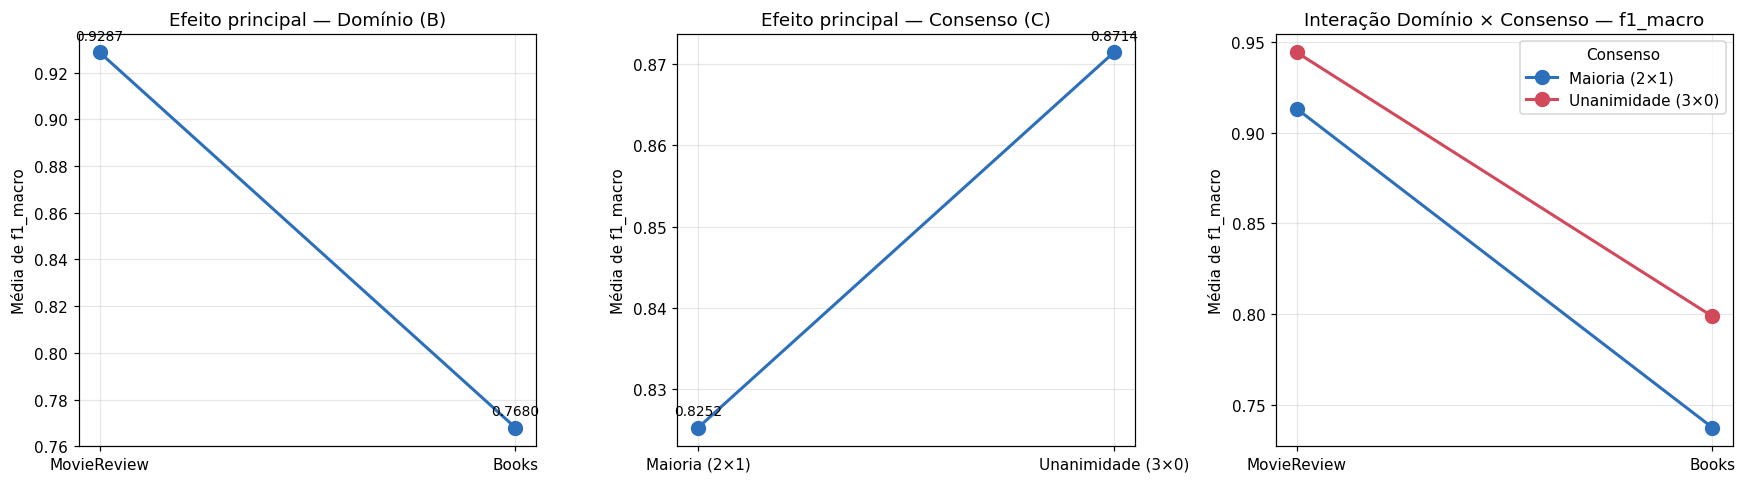

In [15]:
plot_factorial(df_results, "f1_macro")

## 9) Análise fatorial — Resposta = **Acurácia**

In [16]:
res_acc = factorial_2k_analysis(df_results, "accuracy")
print(f"s²_e = {res_acc['s2e']:.6e}   s_q = {res_acc['s_q']:.6e}   "
      f"g.l. erro = {res_acc['df_err']}   t_crit(5%) = {res_acc['t_crit']:.4f}")

s²_e = 9.529921e-07   s_q = 2.182879e-04   g.l. erro = 16   t_crit(5%) = 2.1199


### Médias dos tratamentos (Acurácia)

In [17]:
res_acc["means"]

,tratamento,B,C,BC,media,std,var,n
0,(1),-1,-1,1,0.9132,0.0007,0.0000,5
1,b,1,-1,-1,0.7236,0.0003,0.0000,5
2,c,-1,1,-1,0.9442,0.0011,0.0000,5
3,bc,1,1,1,0.7926,0.0014,0.0000,5


### Matriz de contrastes (Acurácia)

In [18]:
res_acc["contrast"]

,tratamento,I,B,C,BC,media
0,(1),1,-1,-1,1,0.9132
1,b,1,1,-1,-1,0.7236
2,c,1,-1,1,-1,0.9442
3,bc,1,1,1,1,0.7926


### Efeitos fatoriais (Acurácia)

In [19]:
res_acc["effects"]

,fator,q,efeito (2q)
0,B (domínio),-0.0853,-0.1706
1,C (consenso),0.0250,0.0501
2,BC (interação),0.0095,0.0190


### Significância estatística (Acurácia)

In [20]:
res_acc["significance"]

,fator,q,efeito (2q),IC q low,IC q high,t,p_value,significativo (5%),SS,% variação
0,B,-0.0853,-0.1706,-0.0858,-0.0848,-390.8061,0.0000,True,0.1455,91.0199
1,C,0.0250,0.0501,0.0246,0.0255,114.7037,0.0000,True,0.0125,7.8409
2,BC,0.0095,0.0190,0.0090,0.0100,43.5379,0.0000,True,0.0018,1.1297


### Decomposição da variação (Acurácia)

In [21]:
res_acc["ss_table"]

,componente,SS,g.l.,% variação
0,B,0.1455,1,91.0199
1,C,0.0125,1,7.8409
2,BC,0.0018,1,1.1297
3,Erro,0.0000,16,0.0095
4,Total,0.1599,19,100.0000


### Gráficos — Acurácia

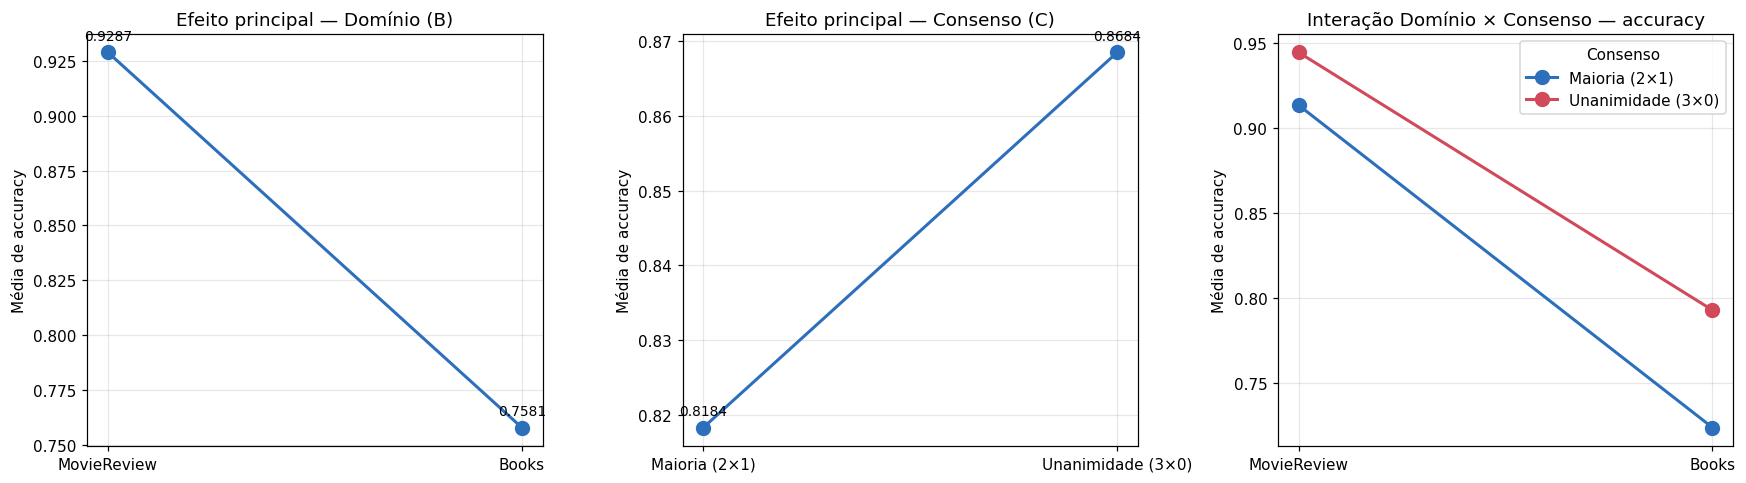

In [22]:
plot_factorial(df_results, "accuracy")

## 10) Resumo / interpretação

Use as **Tabelas de efeitos e de significância** (§8 e §9) para concluir o estudo:

- **Efeito B (Domínio)** — diferença média de desempenho entre Books (técnico) e
  MovieReview (geral). Efeito negativo ⇒ o domínio técnico (Books) reduz a
  qualidade do consenso (tanto em F1 quanto em acurácia).
- **Efeito C (Consenso)** — diferença entre Unanimidade (3×0) e Maioria (2×1).
  Efeito positivo ⇒ exigir unanimidade melhora a qualidade.
- **Efeito BC (Interação)** — se significativo, o efeito de exigir unanimidade
  depende do domínio.
- **Significância**: um efeito é estatisticamente relevante (5%) quando
  `p_value < 0.05` e o intervalo de confiança de `q` não contém zero.
- A coluna **% variação** mostra quanto cada fator explica da variabilidade
  total observada.

In [23]:
def resumo(res, titulo):
    err_pct = 100 * res["SSE"] / res["SST"]
    print(f"=== RESUMO {titulo} ===")
    print(res["effects"].to_string(index=False))
    print()
    print(res["significance"][["fator", "efeito (2q)", "t", "p_value",
                               "significativo (5%)", "% variação"]].to_string(index=False))
    print(f"\nErro experimental: s²_e = {res['s2e']:.3e} | "
          f"SSE = {res['SSE']:.6f} | % variação (erro) = {err_pct:.4f}%")


resumo(res_f1, "F1 MACRO")
print()
resumo(res_acc, "ACURÁCIA")


=== RESUMO F1 MACRO ===
         fator       q  efeito (2q)
   B (domínio) -0.0804      -0.1607
  C (consenso)  0.0231       0.0462
BC (interação)  0.0076       0.0151

fator  efeito (2q)         t  p_value  significativo (5%)  % variação
    B      -0.1607 -343.3156   0.0000                True     91.6068
    C       0.0462   98.6862   0.0000                True      7.5693
   BC       0.0151   32.3121   0.0000                True      0.8115

Erro experimental: s²_e = 1.096e-06 | SSE = 0.000018 | % variação (erro) = 0.0124%

=== RESUMO ACURÁCIA ===
         fator       q  efeito (2q)
   B (domínio) -0.0853      -0.1706
  C (consenso)  0.0250       0.0501
BC (interação)  0.0095       0.0190

fator  efeito (2q)         t  p_value  significativo (5%)  % variação
    B      -0.1706 -390.8061   0.0000                True     91.0199
    C       0.0501  114.7037   0.0000                True      7.8409
   BC       0.0190   43.5379   0.0000                True      1.1297

Erro experimenta

In [24]:
# ===== Exportar análises em .json (data/results/mq/fatorial_2x2) =====
import json

EXPORT_DIR = ROOT / "data" / "results" / "mq" / "fatorial_2x2"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def _to_jsonable(o):
    if isinstance(o, pd.DataFrame):
        return o.to_dict(orient="records")
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return float(o)
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, dict):
        return {k: _to_jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_to_jsonable(v) for v in o]
    return o


payload = {
    "design": "2^2 (B=domínio, C=consenso)",
    "fatores": {
        "B": {"-1": "movie_review", "+1": "books"},
        "C": {"-1": "2x1 (maioria)", "+1": "3x0 (unanimidade)"},
    },
    "n_replicas": N_REPS,
    "resultados_por_replica": _to_jsonable(df_results),
    "analise": {
        "f1_macro": _to_jsonable(res_f1),
        "accuracy": _to_jsonable(res_acc),
    },
}

with open(EXPORT_DIR / "analise_fatorial_2x2.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)
with open(EXPORT_DIR / "resultados_por_replica.json", "w", encoding="utf-8") as f:
    json.dump(_to_jsonable(df_results), f, ensure_ascii=False, indent=2)

print("✓ Análises salvas em:", EXPORT_DIR)
for p in sorted(EXPORT_DIR.glob("*.json")):
    print("  -", p.name)


✓ Análises salvas em: c:\Users\gabri\Documents\GitHub\llm-annotation\data\results\mq\fatorial_2x2
  - analise_fatorial_2x2.json
  - resultados_por_replica.json
